# Substructure Design from Preliminary Reactions

The [Steel Girder Bridge Walkthrough](Steel%20Girder%20Bridge%20Walkthrough.ipynb)
ends where superstructure analysis hands off to substructure design: the
refined grillage is solved in MIDAS and `civilpy.structural.substructure` sums
the bearing reactions onto each abutment and pier, factored into the AASHTO
combinations. This notebook picks up that hand-off and carries the factored
reactions through the substructure checks:

1. **Reactions** - pull the per-unit design reactions from the solved MIDAS
   model (`substructure_reaction_report`), or fall back to the recorded run.
2. **Pier cap** - plug the bearing reactions into a **strut-and-tie model**:
   `stm_topology.design.optimize_pier_cap` sweeps the cap depth, runs the
   topology-optimization pipeline at each depth, and returns the shallowest
   cap whose STM is a complete load path with code-satisfying strut angles
   and nodal zones, with the tie steel proportioned.
3. **Columns / bent** - `civilpy.structural.pier.MultiColumnBent` distributes
   the cap reactions and a lateral force to the columns and runs the
   AASHTO P-M checks, plus the conventional beam-theory cross-checks on the cap.
4. **Abutment** - the same STM optimizer designs the abutment cap on its
   piles, and `civilpy.structural.abutment.RetainingWall` runs the external
   stability checks (overturning / sliding / bearing) on the stem and footing.
5. **Review in Rhino** - `civilpy.structural.rhino_stm` writes the solved STM
   to a tagged `.3dm` (ties red, struts blue) for markup.


In [1]:
from civilpy.structural.bridge_layout import BridgeInput, layout_bridge
from civilpy.structural import substructure as sub

# The walkthrough bridge: 5 spans, 5 x W40X211 @ 9 ft, 40 ft roadway
inp = BridgeInput(spans_ft=(120.0, 150.0, 150.0, 150.0, 120.0),
                  girder_count=5, girder_spacing_ft=9.0,
                  girder_label="W40X211", overhang_ft=2.0,
                  railing="SBR-1-20", grade="Grade 50W",
                  deck_thickness_in=9.0, cross_slope_pct=2.0)
layout = layout_bridge(inp)

units = sub.substructure_units(layout)
for u in units:
    print(f"{u.name:<12} station {u.station_ft:>6.1f} ft")

Abutment 1   station    0.0 ft
Pier 2       station  120.0 ft
Pier 3       station  270.0 ft
Pier 4       station  420.0 ft
Pier 5       station  570.0 ft
Abutment 2   station  690.0 ft


## 1. Design reactions per substructure unit

`substructure_reaction_report` needs a **solved** MIDAS session (the
walkthrough's grillage with its DC1/DC2/DW and lane loads). When MIDAS is not
running, the recorded results of that run are used - the same numbers verified
live in the walkthrough - so the rest of the notebook always executes.
`design_reactions` applies the AASHTO combinations (Strength I: 1.25 DC +
1.5 DW + 1.75 LL; Service I: 1.0 each).

In [2]:
CASES = ["DC1", "DC2", "DW", "LL-LANE"]

# Vertical reactions FZ (kip) per unit and case, recorded from the live
# MIDAS run of the walkthrough grillage (5 spans, 3 design lanes).
RECORDED_FZ = {
    "Abutment 1": {"DC1": 248, "DC2": 41, "DW": 107, "LL-LANE": 73},
    "Pier 2":     {"DC1": 833, "DC2": 137, "DW": 360, "LL-LANE": 245},
    "Pier 3":     {"DC1": 835, "DC2": 137, "DW": 361, "LL-LANE": 245},
    "Pier 4":     {"DC1": 835, "DC2": 137, "DW": 361, "LL-LANE": 245},
    "Pier 5":     {"DC1": 833, "DC2": 137, "DW": 360, "LL-LANE": 245},
    "Abutment 2": {"DC1": 248, "DC2": 41, "DW": 107, "LL-LANE": 73},
}

try:
    from civilpy.structural.midas import MidasCivil
    from civilpy.structural.bridge_layout import grillage_model_from_layout

    midas = MidasCivil()                       # ~/secrets.json credentials
    model = grillage_model_from_layout(layout)
    report = sub.substructure_reaction_report(midas, model, layout, CASES)
    grouped, design = report["by_case"], report["design"]
    print("Reactions pulled from the live MIDAS session.")
except Exception as exc:
    grouped = {unit: {case: (0.0, 0.0, fz, 0.0, 0.0, 0.0)
                      for case, fz in cases.items()}
               for unit, cases in RECORDED_FZ.items()}
    design = sub.design_reactions(grouped)
    print(f"MIDAS session not available ({type(exc).__name__}) - "
          "using the recorded run.")

FZ = 2   # component index in sub.COMPONENTS = (FX, FY, FZ, MX, MY, MZ)
print(f"\n{'unit':<12}{'Strength I':>12}{'Service I':>12}   (FZ, kip)")
for unit, combos in design.items():
    print(f"{unit:<12}{combos['Strength I'][FZ]:>12,.0f}"
          f"{combos['Service I'][FZ]:>12,.0f}")

C:\Users\dane\PycharmProjects\civilpy\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


MIDAS session not available (MidasApiError) - using the recorded run.

unit          Strength I   Service I   (FZ, kip)
Abutment 1           650         469
Pier 2             2,181       1,575
Pier 3             2,185       1,578
Pier 4             2,185       1,578
Pier 5             2,181       1,575
Abutment 2           650         469


## 2. From unit totals to bearing loads

The STM needs the reaction **at each bearing**, not the unit total. The
factored total is distributed to the five girder lines by their deck
tributary widths - the fascia lines carry the overhang plus half a bay, the
interior lines a full bay. This matches the dead-load basis of the
preliminary model; for final design use the per-node reactions the grillage
solves directly (`sub.fetch_support_reactions` keeps them per bearing before
grouping).

In [3]:
s, oh = inp.girder_spacing_ft, inp.overhang_ft
trib = [oh + s / 2] + [s] * (inp.girder_count - 2) + [oh + s / 2]
shares = [t / sum(trib) for t in trib]
bearing_y = [g * s for g in range(inp.girder_count)]     # 0..36 ft across

def bearing_loads(unit, combo="Strength I"):
    total = design[unit][combo][FZ]
    return [round(total * f, 1) for f in shares]

pier_loads = bearing_loads("Pier 2")
abut_loads = bearing_loads("Abutment 1")
print("Pier 2   Strength I bearing loads (kip):", pier_loads)
print("Abutment Strength I bearing loads (kip):", abut_loads)

Pier 2   Strength I bearing loads (kip): [354.5, 490.8, 490.8, 490.8, 354.5]
Abutment Strength I bearing loads (kip): [105.5, 146.1, 146.1, 146.1, 105.5]


## 3. Pier cap as a strut-and-tie model

A hammerhead or bent cap loaded by bearings over columns is a **D-region** -
deep-beam proportions where plane sections do not hold and AASHTO 5.8.2 sends
the designer to a strut-and-tie model.

`optimize_pier_cap` automates the proportioning loop an engineer would
otherwise iterate by hand. For each candidate depth it fills the cap region
with an optimized truss (`stm_topology.pipeline.optimize_to_stm`: SIMP
topology optimization -> truss extraction -> solve -> AASHTO checks) and
accepts the depth only if

* the truss is a **complete, equilibrated load path** - every bearing and
  column participates;
* the flattest primary strut meets the **25 degree nodal-angle limit**
  (AASHTO 5.8.2.5 / the deep-beam a/d limit); and
* every **nodal zone** has capacity for its bearing pressure.

The shallowest passing depth minimizes concrete, which dominates cost. Here
the cap spans the 41 ft bearing spread on two 42 in columns at the third
points.

In [4]:
from civilpy.structural.stm_topology.design import optimize_pier_cap

column_xs = [9.0, 27.0]           # 2-column bent, columns under G2 / G4
pier_cap = optimize_pier_cap(
    pier_loads, load_xs=bearing_y, column_xs=column_xs,
    f_c=4.0, thickness=4.0,       # 48 in wide cap
    depth_bounds=(5.0, 9.0), n_depths=5,
)
print(pier_cap.summary())

Pier-cap depth optimization (span 41 ft, thickness 4 ft):
  optimum depth = 5.0 ft  ->  $27,868  (concrete $25,815 + 1711 lb steel)
  governing: strut angle 29.1 deg >= 25 (a/d limit); nodal capacity/demand 2.14; governing tie 774 kip
  feasible depths: 5.0-9.0 ft


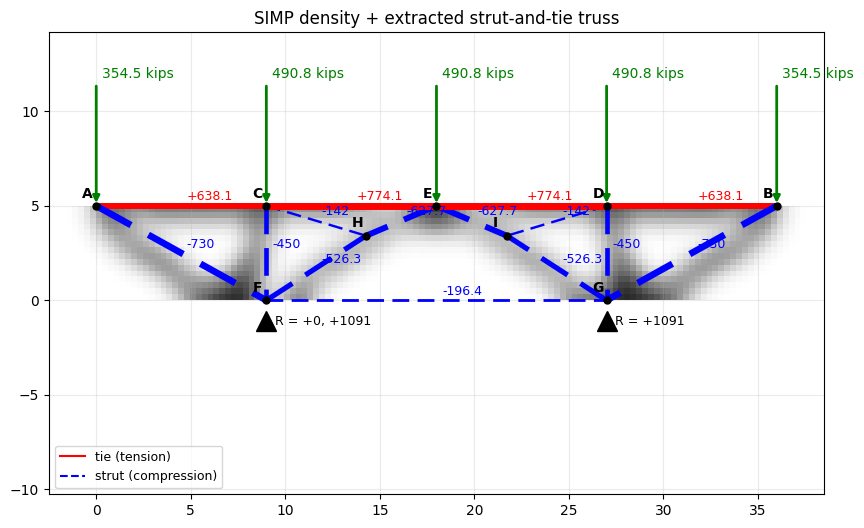

In [5]:
pier_cap.plot();          # SIMP density field + extracted truss

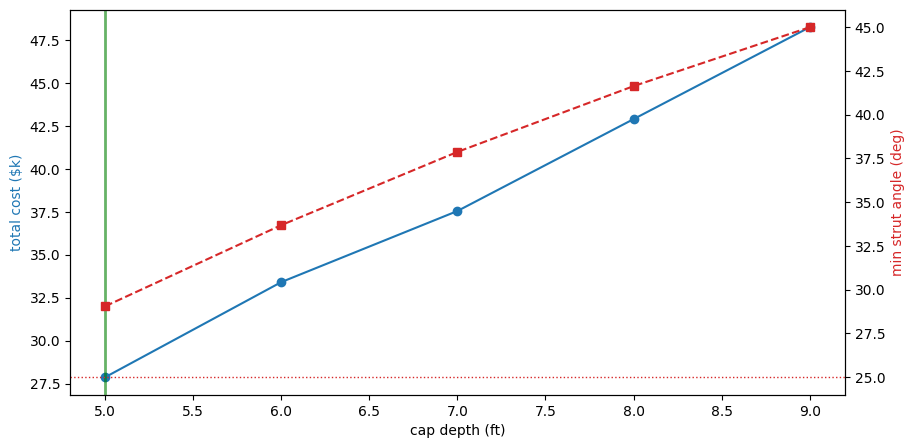

In [6]:
pier_cap.plot_tradeoff();  # cost & strut angle vs depth, optimum marked

The design report proportions every tie (bar count / size vs. the AASHTO
5.8.2.4 tie resistance). The governing bottom tie is what the cap's
longitudinal reinforcement must develop between the columns:

In [7]:
report = pier_cap.report
for tie in sorted(report.ties, key=lambda t: -t.force)[:5]:
    print(f"tie {str(tie.member):<14} {tie.force:>7.1f} kip -> "
          f"{tie.bar_count} x #{tie.bar_size}  "
          f"(As = {tie.a_st_provided:.2f} in^2, D/C = {tie.check.ratio:.2f})")

tie ('C', 'E')       774.1 kip -> 12 x #10  (As = 15.24 in^2, D/C = 1.06)
tie ('E', 'D')       774.1 kip -> 12 x #10  (As = 15.24 in^2, D/C = 1.06)
tie ('A', 'C')       638.1 kip -> 10 x #10  (As = 12.70 in^2, D/C = 1.07)
tie ('B', 'D')       638.1 kip -> 10 x #10  (As = 12.70 in^2, D/C = 1.07)


## 4. Bent: columns and the cap's beam-theory cross-check

`civilpy.structural.pier` models the bent conventionally: the cap as a
continuous beam on the columns (direct-stiffness solve of the bearing point
loads + self weight) and each column through the AASHTO 5.6.4.5 P-M
interaction check with slenderness-magnified moments. This is the B-region
companion to the STM above - shear/flexure checks away from the disturbed
regions, and the axial load + moment each column (and its foundation)
carries. Dimensions in **inches** in this module.

In [8]:
from civilpy.structural.pier import (
    MultiColumnBent, PierCap, PierColumn, PointLoad)
from civilpy.structural.aashto.lrfd.columns import RebarLayer

depth_in = pier_cap.optimal.depth * 12.0
edge_ft = 2.5                                  # cap overhang past bearings
cap = PierCap(
    length=(bearing_y[-1] + 2 * edge_ft) * 12.0, width=48.0, depth=depth_in,
    column_positions=[(x + edge_ft) * 12.0 for x in column_xs],
    loads=[PointLoad((y + edge_ft) * 12.0, p)
           for y, p in zip(bearing_y, pier_loads)],
    f_c=4.0)

column = PierColumn(
    height=25.0 * 12.0, b=42.0, h=42.0, f_c=4.0,
    layers=[RebarLayer(12 * 1.27, 4.0),        # 12 #10 each face
            RebarLayer(12 * 1.27, 38.0)])

bent = MultiColumnBent(cap, [column, column],
                       lateral_force=50.0)     # nominal transverse (wind/BR)
result = bent.analyze()

for i, (p, m, chk) in enumerate(zip(result.column_axials,
                                    result.column_moments,
                                    result.pm_checks), 1):
    print(f"column {i}: Pu = {p:,.0f} kip, magnified Mu = {m/12:,.0f} kip-ft, "
          f"P-M D/C = {chk.demand / chk.capacity:.2f}")

sol = result.cap_solution
a_s = max(t.a_st_provided for t in report.ties)   # STM bottom-tie steel
flex = cap.flexure_check(a_s=a_s, solution=sol)
shear = cap.shear_check(a_v=1.24, s=6.0, solution=sol)  # #7 double stirrups
print(f"\ncap flexure: Mu = {flex.demand/12:,.0f} kip-ft vs "
      f"phi*Mn = {flex.factored_capacity/12:,.0f} kip-ft")
print(f"cap shear:   Vu = {shear.demand:,.0f} kip vs "
      f"phi*Vn = {shear.factored_capacity:,.0f} kip")

column 1: Pu = 1,152 kip, magnified Mu = 312 kip-ft, P-M D/C = 0.08
column 2: Pu = 1,152 kip, magnified Mu = 312 kip-ft, P-M D/C = 0.08

cap flexure: Mu = 3,389 kip-ft vs phi*Mn = 3,678 kip-ft
cap shear:   Vu = 387 kip vs phi*Vn = 844 kip


## 5. Abutment: cap on piles, then external stability

**Cap.** A pile-supported abutment cap is the same D-region problem with the
supports at the piles, so the same optimizer designs it - here the five
bearing reactions land on four piles at roughly 11 ft:

Pier-cap depth optimization (span 41 ft, thickness 4 ft):
  optimum depth = 5.5 ft  ->  $25,220  (concrete $24,847 + 311 lb steel)
  governing: strut angle 45.0 deg >= 25 (a/d limit); nodal capacity/demand 6.06; governing tie 160 kip
  feasible depths: 5.5-6.5 ft

pile service check: 117 kip/pile Service I - compare to the driven capacity from the geotech recommendations (civilpy.geotech.deep_foundation).


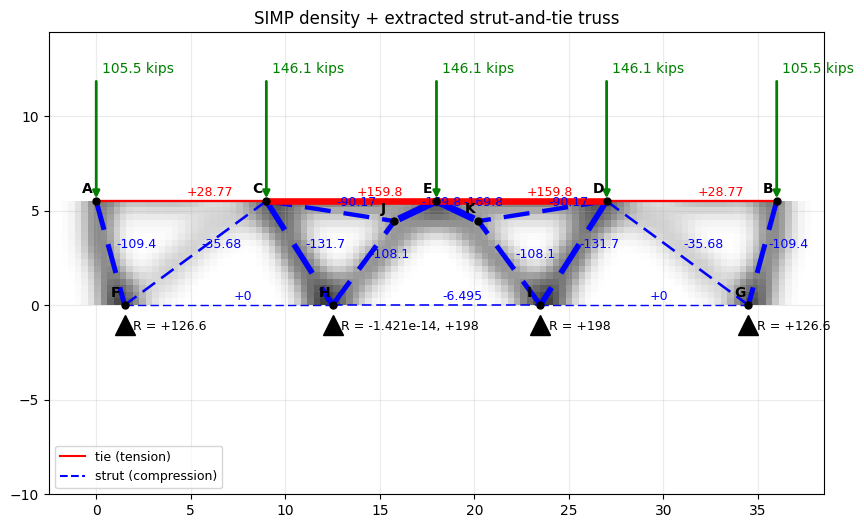

In [9]:
pile_xs = [1.5, 12.5, 23.5, 34.5]
abut_cap = optimize_pier_cap(
    abut_loads, load_xs=bearing_y, column_xs=pile_xs,
    f_c=4.0, thickness=3.5,                    # 42 in wide seat
    depth_bounds=(3.5, 6.5), n_depths=4, nelx=84,
    column_bearing=1.0)                        # 12 in pile head
print(abut_cap.summary())
print("\npile service check: "
      f"{design['Abutment 1']['Service I'][FZ] / len(pile_xs):,.0f} "
      "kip/pile Service I - compare to the driven capacity from the "
      "geotech recommendations (civilpy.geotech.deep_foundation).")
abut_cap.plot();

**External stability.** The stem and footing must also satisfy the classical
overturning / sliding / bearing checks under the retained approach fill.
`civilpy.structural.abutment.RetainingWall` runs them per foot of wall with
Rankine (or Coulomb) pressures and a live-load surcharge on the approach -
the vertical bridge reaction is conservatively omitted from the resisting
side here; the A-1-20 geometry rules live in
`civilpy.structural.odot.typical_abutment`.

In [10]:
from civilpy.structural.abutment import RetainingWall

wall = RetainingWall(
    stem_height=14.0, stem_thickness=3.5,      # seat + backwall to grade
    toe_length=4.0, heel_length=8.0, footing_thickness=3.0,
    backfill_gamma=120.0, backfill_phi=32.0,
    surcharge=250.0,                           # approach LL surcharge, psf
    base_friction_deg=26.0)

stab = wall.stability()
print(f"resisting / overturning moment: {stab.resisting_moment:,.0f} / "
      f"{stab.overturning_moment:,.0f} lb-ft "
      f"(FS = {stab.resisting_moment / stab.overturning_moment:.2f}, "
      f"need {stab.fs_required_overturning})")
print(f"sliding: resistance {stab.details['sliding_resistance']:,.0f} lb vs "
      f"thrust {stab.sum_h:,.0f} lb "
      f"(FS = {stab.details['sliding_resistance'] / stab.sum_h:.2f}, "
      f"need {stab.fs_required_sliding})")
print(f"bearing: e = {stab.eccentricity:.2f} ft "
      f"(B/6 = {stab.base_width / 6:.2f}), "
      f"q_max = {stab.contact.q_max:,.0f} psf")

resisting / overturning moment: 273,879 / 41,291 lb-ft (FS = 6.63, need 2.0)
sliding: resistance 14,517 lb vs thrust 6,634 lb (FS = 2.19, need 1.5)
bearing: e = -0.06 ft (B/6 = 2.58), q_max = 1,968 psf


## 6. Review the STM in Rhino

`civilpy.structural.rhino_stm` writes the solved model as a tagged `.3dm` -
ties red, struts blue, member forces in the user text - the same
geometry-carries-spatial / tags-carry-scalar convention the rest of the
Rhino pipeline uses, so the cap STM can be reviewed and marked up next to
the BrIM bridge model.

In [11]:
from civilpy.structural import rhino_stm

rhino_stm.results_to_3dm(pier_cap.model, "pier_cap_stm_results.3dm")
print("wrote pier_cap_stm_results.3dm")

wrote pier_cap_stm_results.3dm

## 7. The executed design becomes the BrIM model

Phase 4 of the BrIM work plan closes the loop: `substructure_from_layout`
reads its dimensions **out of the design objects above** -- the caps from
`pier_cap` / `abut_cap`, the columns from `bent`, the wingwalls from
`wall` -- and places them under the superstructure layout: cap tops hang
one minimum seat below the lowest bearing stack, and each girder gets a
stepped beam seat following the deck cross slope. `add_substructure`
merges the tagged geometry into the superstructure emit, so the pay-item
rollup, the JSON hand-off to `draw_bim_emit.py`, and the saved-model
read-back all cover the substructure with no extra plumbing.

The only inputs that are *not* design-object pass-throughs are the ones no
civilpy designer sizes yet: the driven pile length (geotech), the footing
plan (geotech), and the wingwall run length (site geometry).

In [12]:
from civilpy.structural.rhino_bim import (
    add_substructure, girder_bridge_emit, pay_item_quantities,
    stm_overlay_emit)
from civilpy.structural.substructure_layout import (
    AbutmentSpec, FootingSpec, substructure_from_layout)

substructure = substructure_from_layout(
    layout, pier_cap=pier_cap, pier_bent=bent, abutment_cap=abut_cap,
    abutment=AbutmentSpec(
        pile_xs_ft=tuple(pile_xs), pile_shape="HP10X42",
        pile_length_ft=40.0,            # geotech-recommended driven length
        wingwall=wall, wingwall_length_ft=12.0),
    footing=FootingSpec(length_ft=12.0, width_ft=12.0, thickness_ft=3.5))

emit = girder_bridge_emit(inp)
full = add_substructure(emit, substructure)
overlay = stm_overlay_emit(pier_cap.model, substructure.piers[0], layout)

n_sub = len(full.objects) - len(emit.objects)
print(f"{n_sub:,} substructure objects + {len(overlay)} STM members "
      f"over {len(emit.objects):,} superstructure objects")
pier1 = substructure.piers[0]
print(f"pier cap top at {pier1.cap.origin[2]:.2f} ft, "
      f"seats {min(s.height_in for s in pier1.seats):.1f}-"
      f"{max(s.height_in for s in pier1.seats):.1f} in "
      "(stepping with the 2% crown)")

1,310 substructure objects + 15 STM members over 8,068 superstructure objects
pier cap top at -5.18 ft, seats 3.0-7.3 in (stepping with the 2% crown)


The estimate now spans both inspection groups -- the 511/507/509
substructure items land next to the superstructure steel, deck, and
railing quantities, every one traceable to a tagged object:

In [13]:
for item, rec in pay_item_quantities(full).items():
    print(f"{item}  {rec['desc'][:52]:<52} {rec['qty']:>12,.1f} {rec['unit']}")

507E10000  Steel piles HP, furnished and driven [CONFIRM]              320.0 ft
509E00200  Epoxy coated reinforcing steel [CONFIRM]                 66,169.3 lb
509E00300  GFRP deformed bars [CONFIRM]                                  0.0 lb
511E12100  Class QC2 concrete, superstructure (deck) [CONFIRM]         800.5 cy
511E40000  Class QC1 concrete, substructure [CONFIRM]                  613.8 cy
512E10000  Concrete, parapet/railing [CONFIRM]                         208.7 cy
513E10220  Structural steel members, Level 1                       733,577.3 lb
513E20000  Shear connectors (welded studs)                           5,175.0 ea
516E10000  Elastomeric bearing [CONFIRM]                                30.0 ea


In [14]:
from civilpy.structural.rhino_bim import BridgeEmit, emit_to_json

# STM overlay rides along on Substructure::STM (ties red / struts blue),
# tagged analysis-only so the rollup above never counts it
with_overlay = BridgeEmit(
    inputs=full.inputs, layout=full.layout,
    objects=full.objects + overlay, doc_tags=full.doc_tags)
with open("bim_emit_with_substructure.json", "w") as f:
    f.write(emit_to_json(with_overlay))
print("wrote bim_emit_with_substructure.json for draw_bim_emit.py")

wrote bim_emit_with_substructure.json for draw_bim_emit.py


---

## Where this leaves us

* **Reactions -> design loads**: per-unit AASHTO Strength/Service reactions
  from the preliminary MIDAS run, distributed to bearings on the tributary
  basis (swap in the grillage's per-node reactions for final design).
* **Pier**: an economical cap depth whose strut-and-tie model passes the
  AASHTO 5.8.2 gates, tie steel proportioned, columns checked for P-M with
  slenderness, and the cap cross-checked in beam theory.
* **Abutment**: the pile-cap STM and per-pile service loads, plus the
  external stability triple check on the stem/footing.
* **BrIM**: the executed designs placed and emitted as tagged geometry
  on the `Substructure::*` layers -- caps, seats, columns, footings,
  HP piles, backwalls, wingwalls, the reinforcing cage from the STM
  bar schedule, and the strut-and-tie overlay -- rolled into the same
  estimate and read-back as the superstructure.

**Preliminary flags for final design:** the lane-only live load (add the
design truck/tandem moving-load envelope for the governing per-pier
reaction); the tributary bearing distribution; the nominal lateral force
(compute wind/braking/temperature per AASHTO Section 3); pile axial capacity
from the geotech report; and load factors beyond Strength I / Service I
(Strength III/V, Extreme Event) where they govern.